# Biometria projekt 2 notebook

### Aleksander Luckner

In [1]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

## Konwersja do ocieni szarości

Przykładowe testowane zdjęcia są ze zbioru MMU Irist Dataset, gdzie dokonana już jest konwersja do odcieni szarości. Dokonujemy konwersji, pownieważ dla tego zbioru nie wpłynie to na wyniki a pozwala na import zdjęć z innych zbiorów.

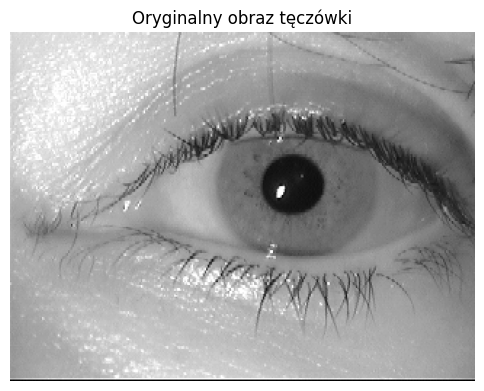

In [41]:
raw = cv2.imread('./images/lecr3.bmp')
if raw is None:
    raise ValueError("Error! Path not found")

img = cv2.cvtColor(raw, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.title("Oryginalny obraz tęczówki")
plt.axis('off')
plt.show()

In [42]:
# wartości ustalone metodą prób i błędów dla wybranego obrazu
x_P = 3.5
x_I = 1.6

In [43]:
h, w = img.shape
# próg binaryzacji jako średnia jasności obrazu
P = np.mean(img) 

P_P = P / x_P
P_I = P / x_I

## Detekcja granic źrenicy

Dla wykrywania granic źrenicy stodujemy maskę 5 x 5 z operacjami kolejno otwarcia i zamknięta. Dzięki temu łatwo wypełniamy dziury w źrenicy i pozbywamy się szumów z wykrywanych rzęs.

In [44]:
_, thresh_pupil = cv2.threshold(img, P_P, 255, cv2.THRESH_BINARY_INV)

kernel = np.ones((7, 7), np.uint8)
morph_pupil = cv2.morphologyEx(thresh_pupil, cv2.MORPH_OPEN, kernel)
morph_pupil = cv2.morphologyEx(morph_pupil, cv2.MORPH_CLOSE, kernel)


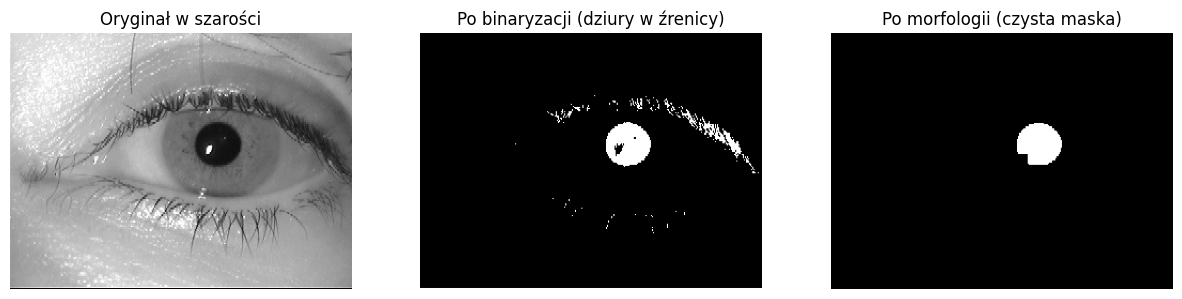

In [45]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Oryginał w szarości")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(thresh_pupil, cmap='gray')
plt.title("Po binaryzacji (dziury w źrenicy)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(morph_pupil, cmap='gray')
plt.title("Po morfologii (czysta maska)")
plt.axis('off')

plt.show()

# Detekcja granic tęczówki

Ze względu na dużo większe szumy spowodowane mniejszym progiem binaryzacji stosujemy maskę 15 x 15 ponownie z operacjami kolejno otwarcia i zamknięcia. Po zastosowaniu operacji widoczne jest spore wcięcie w lewym dolnym rogu, które nie wynika z nachodzenia powiek na tęczówkę. Potencjalnie można spróbować zastosować asymetryczną maskę w celu wypełnienia dziury, jednak w przypadku próby generalidacji programu taka maska nie zadziała. 

In [52]:
_, thresh_iris = cv2.threshold(img, P_I, 255, cv2.THRESH_BINARY_INV)

# większe jądra ze względu na mniejszy próg binaryzacji
kernel_open = np.ones((13, 13), np.uint8) 
kernel_close = np.ones((13, 13), np.uint8)

morph_iris = cv2.morphologyEx(thresh_iris, cv2.MORPH_OPEN, kernel_open)
morph_iris = cv2.morphologyEx(morph_iris, cv2.MORPH_CLOSE, kernel_close)


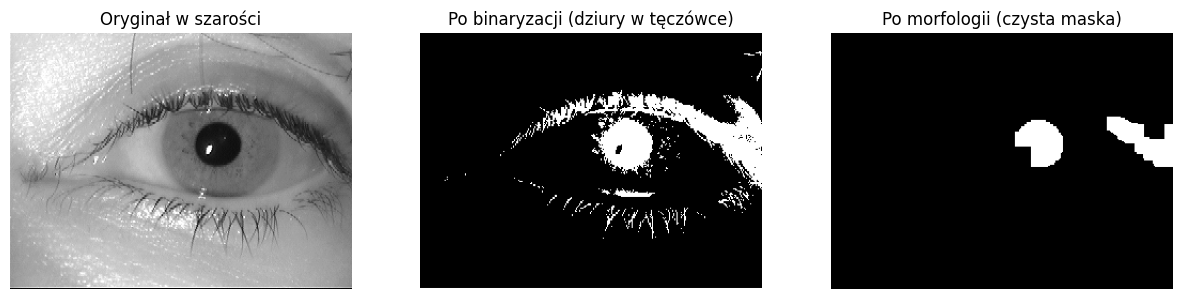

In [53]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Oryginał w szarości")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(thresh_iris, cmap='gray')
plt.title("Po binaryzacji (dziury w tęczówce)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(morph_iris, cmap='gray')
plt.title("Po morfologii (czysta maska)")
plt.axis('off')

plt.show()

## Wyznaczanie środka oraz promieni źrenicy i tęczówki

In [9]:
# Projekcje dla źrenicy
proj_x = np.sum(morph_pupil, axis=0)
proj_y = np.sum(morph_pupil, axis=1)

In [10]:
# Wyznaczanie środka źrenicy
c_x = int(max(proj_x))
c_y = int(max(proj_y))
print(c_x, c_y)


11985 11730


In [11]:
# Wyznaczanie promienia źrenicy
non_zero_x = np.where(proj_x > 0)[0]
r_pupil = int((non_zero_x[-1] - non_zero_x[0]) / 2)
r_pupil

22

In [12]:
proj_x_iris = np.sum(morph_iris, axis=0)
non_zero_x_iris = np.where(proj_x_iris > 0)[0]
r_iris = int((non_zero_x_iris[-1] - non_zero_x_iris[0]) / 2)
r_iris


55

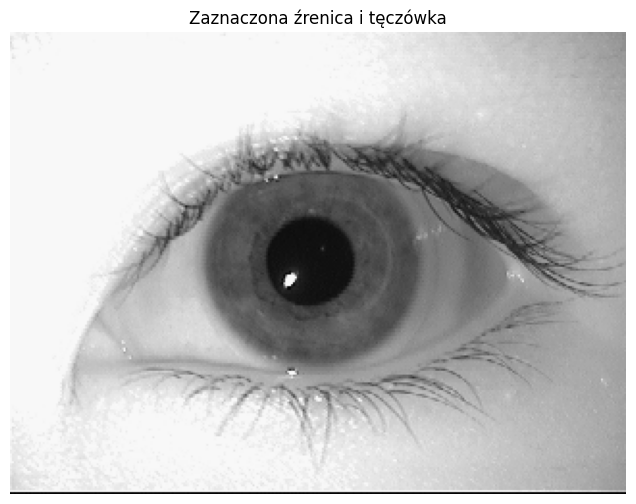

In [13]:
# rysowanie wyznaczonych granic
img_debug = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
cv2.circle(img_debug, (c_x, c_y), r_pupil, (0, 0, 255), 2)
cv2.circle(img_debug, (c_x, c_y), r_iris, (255, 0, 0), 2)
cv2.circle(img_debug, (c_x, c_y), 2, (0, 255, 0), 3)

plt.figure(figsize=(8, 6))
plt.imshow(img_debug)
plt.title("Zaznaczona źrenica i tęczówka")
plt.axis('off')
plt.show()